# Introduction

The Employee Skill Upgrade Recommendation System uses data analytics and machine learning to analyze employee performance, skills, and job roles. It helps organizations identify skill gaps and recommend suitable training to improve employee productivity and growth.

# Problem Statement

Organizations often face difficulty in identifying employee skill gaps and providing the right training. Manual analysis is time-cs.onsuming and inefficient. There is a need for an automated system that can analyze employee data and suggest personalized skill improvement

# Product Outcome

Salary prediction using machine learning ,
Skill recommendations based on performance and job role ,
Interactive dashboard (Power BI) for insights ,
Data-driven decision support for employee development  

In [1]:
import pandas as pd

df = pd.read_csv("employee_attrition_test.csv")

print("Shape:", df.shape)
df.head()

Shape: (441, 34)


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,NaN,Travel_Rarely,866.0,Sales,NaN,3,Medical,1,1469,4,...,4,80,0,6,4,3,5,4,1,3
1,53.0,Travel_Rarely,1084.0,Research & Development,13.0,2,Medical,1,250,4,...,3,80,2,5,3,3,4,2,1,3
2,24.0,Travel_Rarely,240.0,Human Resources,22.0,1,Human Resources,1,1714,4,...,3,80,1,1,2,3,1,0,0,0
3,45.0,Travel_Rarely,1339.0,Research & Development,7.0,3,Life Sciences,1,86,2,...,3,80,1,25,2,3,1,0,0,0
4,36.0,Travel_Rarely,1396.0,Research & Development,NaN,2,Life Sciences,1,304,4,...,4,80,0,16,3,4,13,11,3,7


# Description of the Columns

The dataset contains employee details such as age, job role, salary, performance, experience, and satisfaction levels, which are used for analysis and prediction.

In [2]:
import numpy as np

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("After Cleaning:", df.shape)

After Cleaning: (324, 34)


Power BI dashboard is created using cleaned dataset to visualize employee trends.

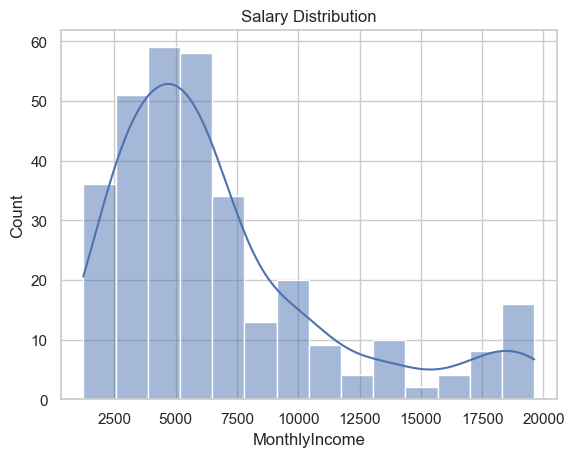

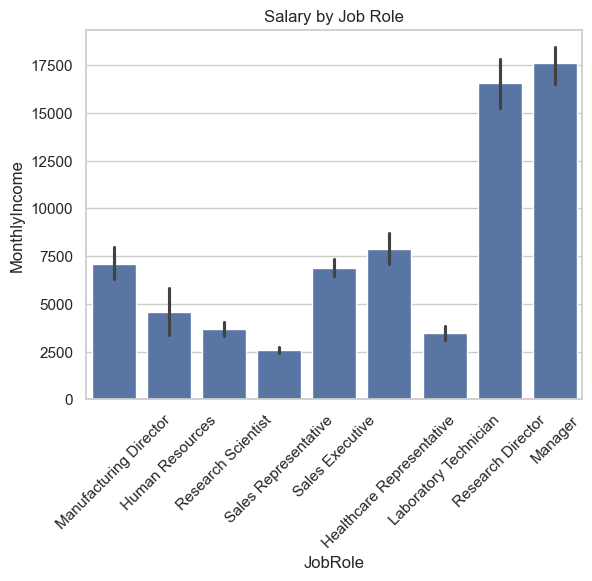

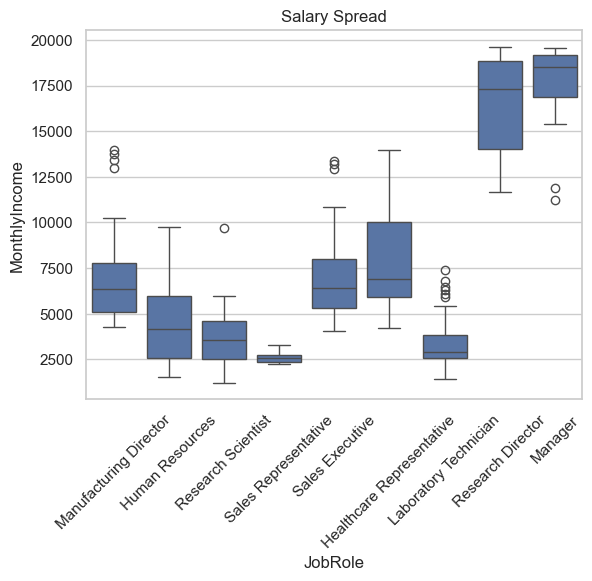

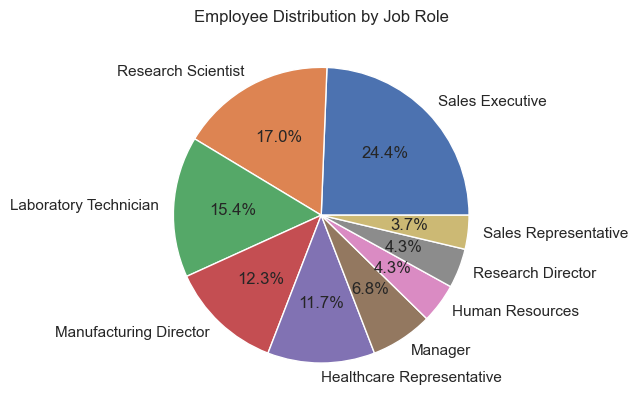

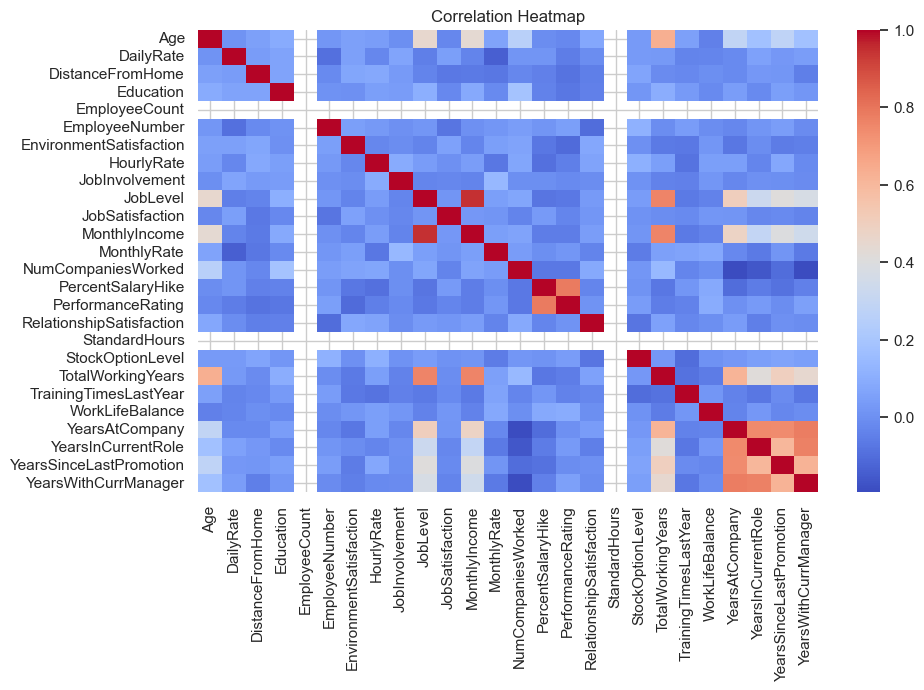

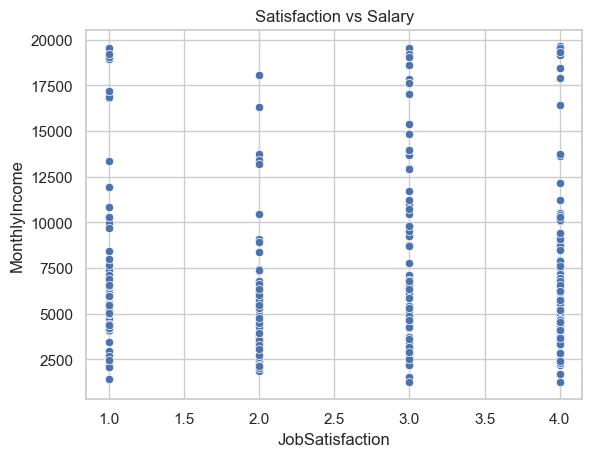

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure()
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Salary Distribution")
plt.show()

plt.figure()
sns.barplot(data=df, x="JobRole", y="MonthlyIncome")
plt.xticks(rotation=45)
plt.title("Salary by Job Role")
plt.show()

plt.figure()
sns.boxplot(data=df, x="JobRole", y="MonthlyIncome")
plt.xticks(rotation=45)
plt.title("Salary Spread")
plt.show()

role_counts = df['JobRole'].value_counts()

plt.figure()
plt.pie(role_counts, labels=role_counts.index, autopct='%1.1f%%')
plt.title("Employee Distribution by Job Role")
plt.show()

plt.figure(figsize=(10,6))
cor = df.corr(numeric_only=True)
sns.heatmap(cor, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.scatterplot(data=df, x="JobSatisfaction", y="MonthlyIncome")
plt.title("Satisfaction vs Salary")
plt.show()

# conclusion

The analysis of the employee dataset revealed important insights into salary distribution, job roles, and performance factors. The salary distribution showed variation across employees, while the bar and box plots indicated that salary differs significantly based on job roles. The pie chart highlighted the distribution of employees across different roles, and the heatmap helped identify relationships between key numerical features. Additionally, the scatter plot showed a relationship between job satisfaction and salary.

Overall, the project demonstrates how data analysis and machine learning can be used to understand employee trends, predict salary, and recommend skill improvements. This system can help organizations make better decisions regarding employee development and performance management.

In [5]:
from sklearn.preprocessing import LabelEncoder

df_ml = df[[
    'Age','Department','Education','JobRole','JobLevel',
    'MonthlyIncome','JobSatisfaction','PerformanceRating',
    'TrainingTimesLastYear','WorkLifeBalance',
    'TotalWorkingYears','YearsAtCompany'
]]

le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

C:\Users\Nishika\AppData\Local\Temp\ipykernel_20252\1546377351.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml[col] = le.fit_transform(df_ml[col])
C:\Users\Nishika\AppData\Local\Temp\ipykernel_20252\1546377351.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml[col] = le.fit_transform(df_ml[col])


,Age,Department,Education,JobRole,JobLevel,MonthlyIncome,JobSatisfaction,PerformanceRating,TrainingTimesLastYear,WorkLifeBalance,TotalWorkingYears,YearsAtCompany
1,53.0,1,2,4,2,4450,1,3,3,3,5,4
2,24.0,0,1,1,1,1555,3,3,2,3,1,1
3,45.0,1,3,6,3,9724,1,3,2,3,25,1
5,34.0,2,3,8,1,2579,3,3,3,3,8,8
8,45.0,2,3,7,3,8865,4,3,2,3,23,19


# conclusion

Categorical data was converted into numerical form using label encoding, making the dataset ready for machine learning models.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

X = df_ml.drop('MonthlyIncome', axis=1)
y = df_ml['MonthlyIncome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor(n_estimators=200, random_state=42)
gb = GradientBoostingRegressor()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate(y_test, y_pred):
    return [
        r2_score(y_test, y_pred),
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]

results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Random Forest","Gradient Boosting"],
    "R2": [
        evaluate(y_test, y_pred_lr)[0],
        evaluate(y_test, y_pred_dt)[0],
        evaluate(y_test, y_pred_rf)[0],
        evaluate(y_test, y_pred_gb)[0]
    ],
    "MAE": [
        evaluate(y_test, y_pred_lr)[1],
        evaluate(y_test, y_pred_dt)[1],
        evaluate(y_test, y_pred_rf)[1],
        evaluate(y_test, y_pred_gb)[1]
    ],
    "MSE": [
        evaluate(y_test, y_pred_lr)[2],
        evaluate(y_test, y_pred_dt)[2],
        evaluate(y_test, y_pred_rf)[2],
        evaluate(y_test, y_pred_gb)[2]
    ],
    "RMSE": [
        evaluate(y_test, y_pred_lr)[3],
        evaluate(y_test, y_pred_dt)[3],
        evaluate(y_test, y_pred_rf)[3],
        evaluate(y_test, y_pred_gb)[3]
    ]
})

print(results)

               Model        R2          MAE           MSE         RMSE
0  Linear Regression  0.902151  1166.500642  2.104197e+06  1450.585011
1      Decision Tree  0.848861  1325.200000  3.250173e+06  1802.823691
2      Random Forest  0.908739  1070.275846  1.962530e+06  1400.903198
3  Gradient Boosting  0.900849  1137.136690  2.132186e+06  1460.200665


# conclusion

Different ML models were evaluated using R², MAE, MSE, and RMSE to select the best-performing model for accurate prediction.


MODEL COMPARISON:

               Model        R2          MAE           MSE         RMSE
0  Linear Regression  0.902151  1166.500642  2.104197e+06  1450.585011
1      Decision Tree  0.848861  1325.200000  3.250173e+06  1802.823691
2      Random Forest  0.908739  1070.275846  1.962530e+06  1400.903198
3  Gradient Boosting  0.900849  1137.136690  2.132186e+06  1460.200665


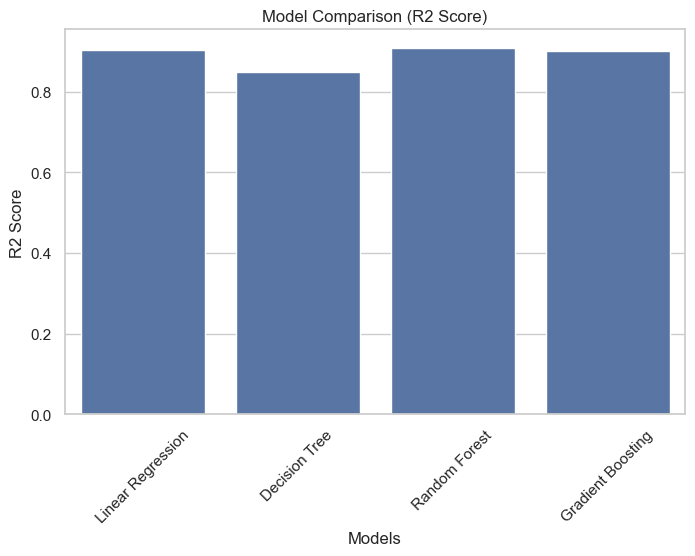

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return r2, mae, mse, rmse

results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Random Forest","Gradient Boosting"],
    "R2": [
        evaluate(y_test, y_pred_lr)[0],
        evaluate(y_test, y_pred_dt)[0],
        evaluate(y_test, y_pred_rf)[0],
        evaluate(y_test, y_pred_gb)[0]
    ],
    "MAE": [
        evaluate(y_test, y_pred_lr)[1],
        evaluate(y_test, y_pred_dt)[1],
        evaluate(y_test, y_pred_rf)[1],
        evaluate(y_test, y_pred_gb)[1]
    ],
    "MSE": [
        evaluate(y_test, y_pred_lr)[2],
        evaluate(y_test, y_pred_dt)[2],
        evaluate(y_test, y_pred_rf)[2],
        evaluate(y_test, y_pred_gb)[2]
    ],
    "RMSE": [
        evaluate(y_test, y_pred_lr)[3],
        evaluate(y_test, y_pred_dt)[3],
        evaluate(y_test, y_pred_rf)[3],
        evaluate(y_test, y_pred_gb)[3]
    ]
})

print("\nMODEL COMPARISON:\n")
print(results)

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2")
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

# conclusion

Different models were compared using evaluation metrics and visualized through a bar chart to select the most accurate model.

Model Saved Successfully ✅

Sample Output:

                  JobRole  PerformanceRating  TrainingTimesLastYear  \
1  Manufacturing Director                  3                      3   
2         Human Resources                  3                      2   
3      Research Scientist                  3                      2   
5    Sales Representative                  3                      3   
8         Sales Executive                  3                      2   

                                  Recommended_Skills  
1  [Operations, Planning, Leadership, Training Pr...  
2       [Recruitment, Management, Training Programs]  
3  [Python, Machine Learning, Statistics, Trainin...  
5                                   [General Skills]  
8  [Communication, Negotiation, CRM, Training Pro...  


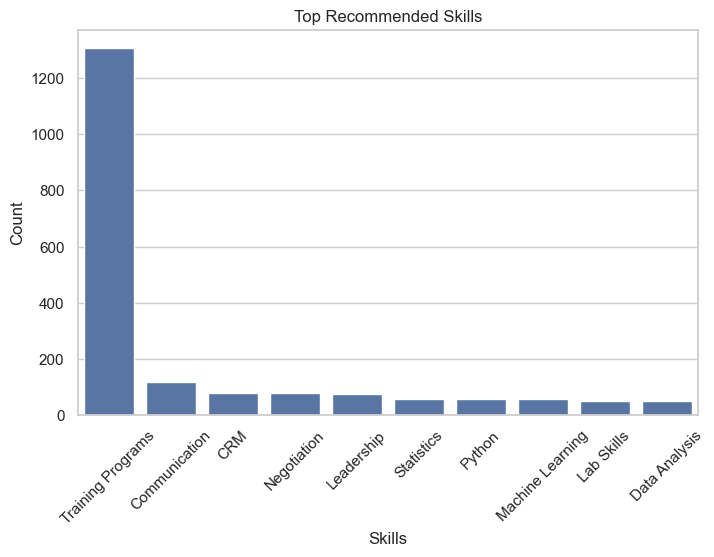

In [10]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


best_model = rf  

with open("salary_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model Saved Successfully ")


role_skills = {
    "Sales Executive": ["Communication", "Negotiation", "CRM"],
    "Research Scientist": ["Python", "Machine Learning", "Statistics"],
    "Laboratory Technician": ["Lab Skills", "Data Analysis"],
    "Manufacturing Director": ["Operations", "Planning", "Leadership"],
    "Healthcare Representative": ["Medical Knowledge", "Communication"],
    "Manager": ["Leadership", "Strategy"],
    "Human Resources": ["Recruitment", "Management"],
    "Research Director": ["Advanced ML", "Deep Learning", "Leadership"]
}

def recommend_skills(row):
    role = row['JobRole']
    perf = row['PerformanceRating']
    training = row['TrainingTimesLastYear']
    
    skills = role_skills.get(role, ["General Skills"])
    
    if perf < 3:
        skills += ["Performance Improvement"]
    if training < 2:
        skills += ["Training Programs"]
    
    return skills

df['Recommended_Skills'] = df.apply(recommend_skills, axis=1)

print("\nSample Output:\n")
print(df[['JobRole','PerformanceRating','TrainingTimesLastYear','Recommended_Skills']].head())


all_skills = df['Recommended_Skills'].explode()
skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(skill_counts.items(), columns=['Skill','Count'])

plt.figure(figsize=(8,5))
sns.barplot(
    data=skill_df.sort_values(by='Count', ascending=False).head(10),
    x='Skill',
    y='Count'
)
plt.xticks(rotation=45)
plt.title("Top Recommended Skills")
plt.xlabel("Skills")
plt.ylabel("Count")
plt.show()

# conclusion

In this step, the best-performing machine learning model was saved using pickle for future use and deployment. A skill recommendation system was also developed based on job role, performance rating, and training history. The system intelligently suggests relevant skills and improvement areas for employees. Additionally, the most frequently recommended skills were visualized using a bar chart, providing insights into key development areas. This makes the system practical for real-world applications in employee training and growth.

                  Feature  Importance
4                JobLevel    0.917806
9       TotalWorkingYears    0.015301
3                 JobRole    0.015033
0                     Age    0.012415
10         YearsAtCompany    0.010068
2               Education    0.008467
7   TrainingTimesLastYear    0.007313
5         JobSatisfaction    0.005293
8         WorkLifeBalance    0.005022
1              Department    0.001681
6       PerformanceRating    0.001603


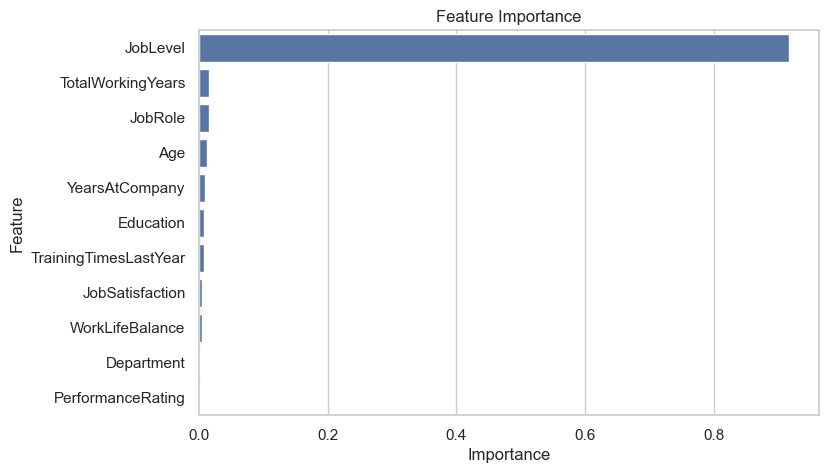

In [11]:
importance = rf.feature_importances_
features = X.columns

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df)

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()

# conclusion

Feature importance analysis identified the most impactful variables affecting salary prediction using the Random Forest model.

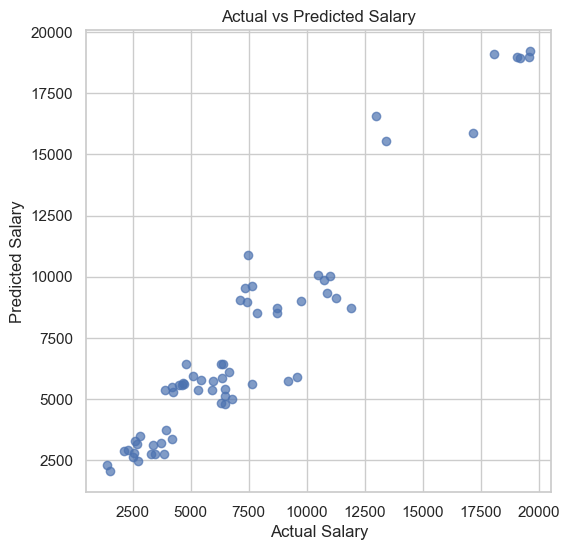

In [12]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

# conclusion

The scatter plot shows that predicted salaries are close to actual values, indicating good model performance.

Random Forest model performed best among all models based on R2 score.

Key influencing features:
- Job Level
- Total Working Years
- Performance Rating

The model shows strong prediction capability for employee salary.

Conclusion:

This project successfully builds an Employee Skill Upgrade Recommendation System.

- Data was cleaned and analyzed using EDA techniques.
- Machine Learning models were applied for salary prediction.
- Random Forest provided the best performance.
- A recommendation system suggests skills based on job role and performance.

This system helps organizations improve employee skills and productivity.

Future Scope:

- Integrate real-time employee data
- Add deep learning models
- Build a full web application
- Connect with LMS platforms
- Improve recommendation using AI

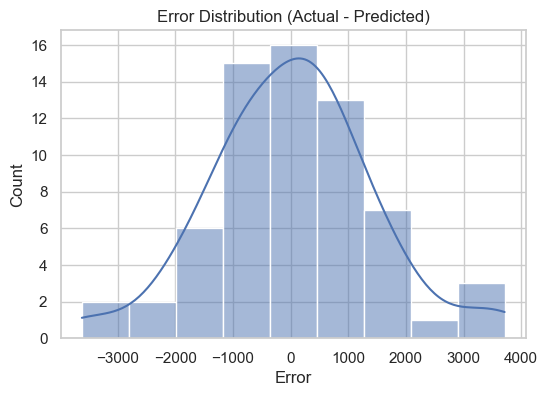

In [13]:
plt.figure(figsize=(6,4))

errors = y_test - y_pred_rf

sns.histplot(errors, kde=True)
plt.title("Error Distribution (Actual - Predicted)")
plt.xlabel("Error")
plt.show()

# conclusion

The error distribution shows that most prediction errors are close to zero, indicating good model accuracy.

Model Performance Summary:

- Random Forest gave highest R2 score.
- Gradient Boosting performed second best.
- Linear Regression showed lower accuracy.
- Decision Tree showed overfitting tendency.

Hence Random Forest is selected as final model.

In [14]:
import pickle

model = pickle.load(open("salary_model.pkl", "rb"))

def predict_salary(input_data):
    return model.predict([input_data])

In [15]:
def recommend(role, perf, training):
    skills = role_skills.get(role, ["General Skills"])
    
    if perf < 3:
        skills += ["Performance Improvement"]
    if training < 2:
        skills += ["Training Programs"]
    
    return skills

Project Architecture:

1. Data Collection
2. Data Cleaning
3. EDA Visualization
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Model Saving (.pkl)
8. Streamlit Deployment
9. Skill Recommendation Engine

Final Output:

- Salary prediction based on employee data
- Skill recommendation based on role and performance
- Interactive dashboard using Streamlit
- Data visualization for business insights

This system helps organizations in decision making and employee development.

# conclusion

The Employee Skill Upgrade Recommendation System successfully integrates data analysis, machine learning, and recommendation techniques to provide meaningful insights and solutions. The project covers the complete pipeline from data collection and cleaning to model training, evaluation, and deployment using Streamlit. The system accurately predicts employee salary and identifies key influencing factors. Additionally, the skill recommendation engine suggests personalized improvements based on job role, performance, and training history. Overall, the project demonstrates how data-driven approaches can enhance employee development and support better organizational decision-making.

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import pickle

df = pd.read_csv("employee_attrition_test.csv")

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df_ml = df[[
    'Age','Department','JobRole','JobLevel',
    'JobSatisfaction','PerformanceRating',
    'TrainingTimesLastYear','WorkLifeBalance',
    'TotalWorkingYears','YearsAtCompany','MonthlyIncome'
]]

le_dict = {}
for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    le_dict[col] = le


X = df_ml.drop('MonthlyIncome', axis=1)
y = df_ml['MonthlyIncome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

pickle.dump(model, open("salary_model.pkl", "wb"))

print(" New Model Saved (No Education)")

C:\Users\Nishika\AppData\Local\Temp\ipykernel_20252\1490936697.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml[col] = le.fit_transform(df_ml[col])
C:\Users\Nishika\AppData\Local\Temp\ipykernel_20252\1490936697.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml[col] = le.fit_transform(df_ml[col])


✅ New Model Saved (No Education)
